## 1. Import libraries

In [25]:
%pip install -q -U ultralytics

In [26]:
# !pip install -U gdown ultralytics scikit-learn albumentations
import ultralytics
import os
import shutil    # ghép file (copy images sang thư mục train/val/test)
import xml.etree.ElementTree as ET
import yaml      # đọc/ghi file .yml
from sklearn.model_selection import train_test_split  #hàm train_test_split

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
ultralytics.checks()

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.6/112.6 GB disk)


In [29]:
# You can run this to check if the model is working
# !yolo predict model=yolo11n.pt source='https://ultralytics.com/images/bus.jpg'

## 2. Trích xuất dữ liệu từ XML và lưu theo định dạng YOLO

In [30]:
def extract_data_from_xml(path):
    tree = ET.parse(path)
    root = tree.getroot()

    image_paths = []  # lưu đường dẫn từng ảnh.
    image_sizes = []
    image_labels = []
    bounding_boxes = []

    for image in root:
        bbs_of_image = []    # tất cả bbox (x, y, w, h) của ảnh đó.
        labels_of_image = [] # text tương ứng với từng bbox.

        for bbs in image.findall("taggedRectangles"):
            for bb in bbs:
                 # Kiểm tra nhãn (text) có hợp lệ không
                # Nếu ký tự đầu tiên không phải là chữ cái hoặc số → bỏ qua bbox này
                if not bb[0].text.isalnum():
                    continue

                # Nếu nhãn chứa ký tự đặc biệt "é" hoặc "ñ" → bỏ qua
                # (tránh lỗi encoding hoặc ký tự không chuẩn trong dataset)
                if "é" in bb[0].text.lower() or "ñ" in bb[0].text.lower():
                    continue

                # Nếu hợp lệ → thêm toạ độ bbox vào danh sách
                bbs_of_image.append(
                    [
                        float(bb.attrib["x"]),       # toạ độ góc trên trái (x)
                        float(bb.attrib["y"]),       # toạ độ góc trên trái (y)
                        float(bb.attrib["width"]),   # chiều rộng bbox
                        float(bb.attrib["height"]),  # chiều cao bbox
                    ]
                )

                # Thêm nhãn tương ứng (text trong thẻ con của <taggedRectangle>)
                labels_of_image.append(bb[0].text.lower())

        # Store
        image_paths.append(image[0].text)   # Đường dẫn ảnh (từ node con đầu tiên)
        # Kích thước ảnh (lưu giá trị thuộc tính x, y từ node thứ 2)
        image_sizes.append((int(image[1].attrib["x"]), int(image[1].attrib["y"])))
        bounding_boxes.append(bbs_of_image)   # Danh sách bbox của ảnh
        image_labels.append(labels_of_image)  # Danh sách nhãn của ảnh

    return image_paths, image_sizes, image_labels, bounding_boxes

In [31]:
dataset_dir = 'drive/MyDrive/TGMT_CK/SceneTrialTrain'
words_xml_path = os.path.join(dataset_dir, "words.xml")
image_paths, image_sizes, image_labels, bounding_boxes = extract_data_from_xml(
    words_xml_path
)

In [32]:
print(f"Number of images: {len(image_paths)}")
print(f"Example image path: {image_paths[0]}")
print(f"Example image size: {image_sizes[0]}")
print(f"Example bounding boxes: {bounding_boxes[0][:2]}")
print(f"Example labels: {image_labels[0][:2]}")

Number of images: 250
Example image path: apanar_06.08.2002/IMG_1261.JPG
Example image size: (1600, 1200)
Example bounding boxes: [[174.0, 392.0, 274.0, 195.0], [512.0, 391.0, 679.0, 183.0]]
Example labels: ['self', 'adhesive']


## 3. Chuyển sang định dạng YOLO

In [33]:
def convert_to_yolo_format(image_paths, image_sizes, bounding_boxes):
    yolo_data = []

    for image_path, image_size, bboxes in zip(image_paths, image_sizes, bounding_boxes):
        image_width, image_height = image_size   # giải nén

        yolo_labels = [] # ds

        # Duyệt qua từng bounding box trong ảnh hiện tại
        for bbox in bboxes:
            x, y, w, h = bbox   # Giải nén toạ độ bbox gốc (theo pixel)

            # rồi chuẩn hoá về khoảng [0, 1] bằng cách chia cho kích thước ảnh
            center_x = (x + w / 2) / image_width
            center_y = (y + h / 2) / image_height

             # Chuẩn hoá chiều rộng và chiều cao bbox
            normalized_width = w / image_width
            normalized_height = h / image_height

            # Vì dataset chỉ có một lớp (text), ta gán class_id = 0 cho tất cả
            class_id = 0

            # Gộp thông tin theo định dạng YOLO:
            #   class_id x_center y_center width height
            # (tất cả đều là số thực chuẩn hoá từ 0–1)
            yolo_label = f"{class_id} {center_x} {center_y} {normalized_width} {normalized_height}"
            yolo_labels.append(yolo_label)

        yolo_data.append((image_path, yolo_labels))

    return yolo_data

In [34]:
# Define class labels
class_labels = ["text"]

# Convert data into YOLO format
yolo_data = convert_to_yolo_format(image_paths, image_sizes, bounding_boxes)

## 4. Train, val, test split

In [35]:
# train 80, val 2,5, test 17,5
seed = 0
val_size = 0.2   # 20%
test_size = 0.125  # Tỷ lệ dữ liệu dành cho tập test (12.5% của phần test/val)
is_shuffle = True  # trộn ngẫu nhiên

# Chia tập YOLO_data thành:
#   - train_data: 80% dữ liệu
#   - test_data: 20% dữ liệu (tạm thời sẽ được chia lại thành test + val)
train_data, test_data = train_test_split(
    yolo_data,
    test_size=val_size,
    random_state=seed,
    shuffle=is_shuffle,
)

# Từ phần test_data (20%), tiếp tục chia tiếp:
#   - test_data: ~87.5% của 20% ban đầu (~17.5% tổng dữ liệu)
#   - val_data:  ~12.5% của 20% ban đầu (~2.5% tổng dữ liệu)
# => Tạo 3 tập riêng biệt: train_data, val_data, test_data
test_data, val_data = train_test_split(
    test_data,
    test_size=test_size,
    random_state=seed,
    shuffle=is_shuffle,
)

## 5. Save data

In [36]:
def save_data(data, src_img_dir, save_dir):

    # Tạo thư mục chính (save_dir) nếu chưa tồn tại
    os.makedirs(save_dir, exist_ok=True)

    # Tạo 2 thư mục con:
    #   - "images" để chứa ảnh
    #   - "labels" để chứa file nhãn (.txt)
    os.makedirs(os.path.join(save_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(save_dir, "labels"), exist_ok=True)

    for image_path, yolo_labels in data:
        # Copy ảnh gốc từ thư mục nguồn (src_img_dir) sang thư mục "images" đích
        shutil.copy(
            os.path.join(src_img_dir, image_path), os.path.join(save_dir, "images")
        )

        # Lấy tên file ảnh (ví dụ: "IMG_1234.jpg")
        image_name = os.path.basename(image_path)
        # Loại bỏ phần đuôi mở rộng (.jpg → IMG_1234)
        image_name = os.path.splitext(image_name)[0]

        with open(os.path.join(save_dir, "labels", f"{image_name}.txt"), "w") as f:
            for label in yolo_labels:
                f.write(f"{label}\n")

In [37]:

save_yolo_data_dir = "drive/MyDrive/TGMT_CK/yolo_data"
# Tạo thư mục gốc này nếu chưa tồn tại (tránh lỗi khi ghi file)
os.makedirs(save_yolo_data_dir, exist_ok=True)
# Thư mục chứa dữ liệu huấn luyện
save_train_dir = os.path.join(save_yolo_data_dir, "train")
save_val_dir = os.path.join(save_yolo_data_dir, "val")
save_test_dir = os.path.join(save_yolo_data_dir, "test")

save_data(train_data, dataset_dir, save_train_dir)
save_data(test_data, dataset_dir, save_val_dir)
save_data(val_data, dataset_dir, save_test_dir)

## 6. Tạo file yaml

In [38]:
# cho yolo dataset nằm đâu bn class
data_yaml = {
    "path": "drive/MyDrive/TGMT_CK/yolo_data",
    "train": "train/images",   # Ảnh dùng để huấn luyện
    "test": "test/images",     # Ảnh dùng để kiểm thử
    "val": "val/images",       # Ảnh dùng để xác thực (validation)
    "nc": 1,                   # Ở đây dataset chỉ có 1 lớp là "text"
    "names": class_labels,
}

yolo_yaml_path = os.path.join(save_yolo_data_dir, "data.yml")
with open(yolo_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

## 7. Training

In [39]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11m.pt")

# Train model
results = model.train(
    data=yolo_yaml_path,
    epochs=20,
    imgsz=640,
    cache=True,
    patience=20,
    plots=True,
)

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=drive/MyDrive/TGMT_CK/yolo_data/data.yml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=Tr

In [40]:
# YOLO luôn theo dõi model nào tốt nhất dựa trên: mAP50 trên tập validation
!cp -r /content/runs/ /content/drive/MyDrive/TGMT_CK/


## 8. Đánh giá

In [41]:
from ultralytics import YOLO

model_path = str(results.save_dir) + '/weights/best.pt'
model = YOLO(model_path)

metrics = model.val()

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.3 ms, read: 32.0±22.1 MB/s, size: 102.3 KB)
val: Scanning /content/drive/MyDrive/TGMT_CK/yolo_data/val/labels.cache... 43 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 62.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.1s
                   all         43        200      0.867      0.812      0.879      0.642
Speed: 6.0ms preprocess, 22.0ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val


## 9. Inference

In [42]:
import json

import cv2
import matplotlib.pyplot as plt


def visualize_bbox(
    img_path, predictions, conf_thres=0.8, font=cv2.FONT_HERSHEY_SIMPLEX
):
    img = cv2.imread(img_path)
    # Lấy chiều cao (h) và chiều rộng (w) của ảnh
    h, w = img.shape[:2]

    for prediction in predictions:
        conf_score = prediction["confidence"]

        if conf_score < conf_thres:
            continue

        bbox = prediction["box"]
        xmin = int(bbox["x1"])   # Tọa độ góc trái trên (x)
        ymin = int(bbox["y1"])   # Tọa độ góc trái trên (y)
        xmax = int(bbox["x2"])   # Tọa độ góc phải dưới (x)
        ymax = int(bbox["y2"])   # Tọa độ góc phải dưới (y)

        # Vẽ hình chữ nhật (bounding box) lên ảnh bằng màu xanh lá (0,255,0)
        # Độ dày khung là 3 pixel
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

        text = f"{conf_score:.2f}"
        (text_width, text_height), _ = cv2.getTextSize(text, font, 1, 2)

        cv2.rectangle(
            img,
            (xmin, ymin - text_height - 5),
            (xmin + text_width, ymin),
            (0, 255, 0),
            -1,
        )
        cv2.putText(img, text, (xmin, ymin - 5), font, 1, (0, 0, 0), 2)

    return img

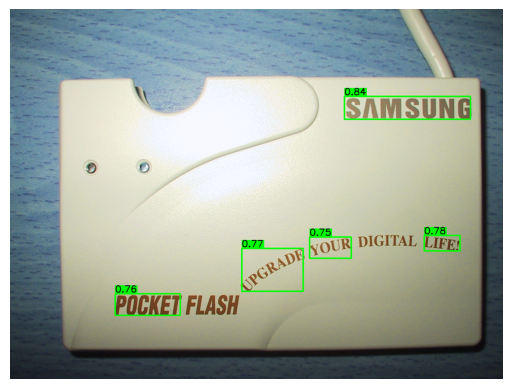

In [44]:
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/TGMT_CK/runs/detect/train/weights/best.pt"
img_path = "/content/drive/MyDrive/TGMT_CK/SceneTrialTrain/apanar_06.08.2002/IMG_1255.JPG"
conf_thres = 0.75
model = YOLO(model_path)

# Run inference
results = model(img_path, verbose=False)
predictions = json.loads(results[0].to_json())
visualized_img = visualize_bbox(img_path, predictions, conf_thres)

%matplotlib inline
plt.imshow(visualized_img)
plt.axis("off")
plt.show()